# Train model using HR normalized on AB

After consideration for simplifying the model.
I chose focus on HR because it's significance as a offensive result.
By normalizing it to AB will make it more fair for players that have more AB and thus more HR

In [14]:
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data/Batting.csv')

# Over data

In [15]:
print("Shape of dataset:", df.shape)
print("\nSummary statistics:")
display(df.describe(include='all'))

Shape of dataset: (101332, 22)

Summary statistics:


,playerID,yearID,stint,teamID,lgID,G,AB,R,H,2B,...,RBI,SB,CS,BB,SO,IBB,HBP,SH,SF,GIDP
count,101332,101332.000000,101332.000000,101332,100595,101332.000000,96183.000000,96183.000000,96183.000000,96183.000000,...,95759.000000,94883.000000,72729.000000,96183.000000,88345.000000,59620.000000,93373.000000,89845.000000,60151.000000,70075.000000
unique,18659,NaN,NaN,149,6,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,mcguide01,NaN,NaN,CHN,NL,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,31,NaN,NaN,4818,51385,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,1963.506533,1.077567,NaN,NaN,51.400111,149.970327,19.887038,39.261647,6.637067,...,17.965163,3.158184,1.324025,13.811484,21.629849,1.213234,1.113395,2.457900,1.150122,3.210032
std,NaN,38.628278,0.283676,NaN,NaN,47.145273,186.557072,28.671365,53.310941,9.801563,...,26.756514,7.922994,2.838196,21.092775,28.432978,2.894918,2.320660,4.347818,2.023981,4.835881
min,NaN,1871.000000,1.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,1933.000000,1.000000,NaN,NaN,13.000000,7.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,NaN,1972.000000,1.000000,NaN,NaN,34.000000,57.000000,5.000000,11.000000,1.000000,...,4.000000,0.000000,0.000000,3.000000,10.000000,0.000000,0.000000,1.000000,0.000000,1.000000
75%,NaN,1997.000000,1.000000,NaN,NaN,80.250000,251.000000,30.000000,63.000000,10.000000,...,27.000000,2.000000,1.000000,20.000000,30.000000,1.000000,1.000000,3.000000,2.000000,5.000000


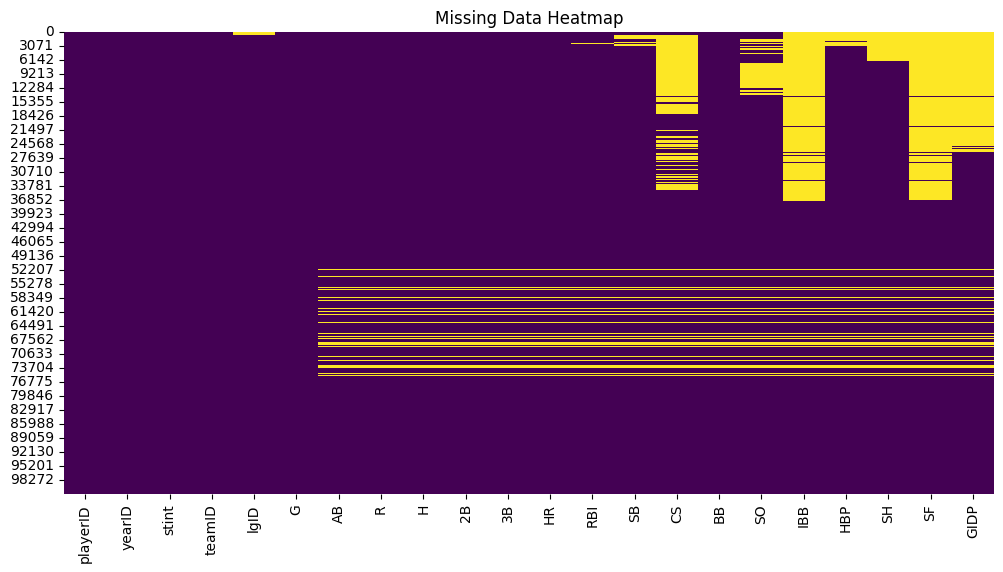

IBB         41712
SF          41181
GIDP        31257
CS          28603
SO          12987
SH          11487
HBP          7959
SB           6449
RBI          5573
HR           5149
R            5149
AB           5149
3B           5149
2B           5149
H            5149
BB           5149
lgID          737
G               0
playerID        0
teamID          0
stint           0
yearID          0
dtype: int64

In [16]:
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Data Heatmap")
plt.show()

df.isnull().sum().sort_values(ascending=False)

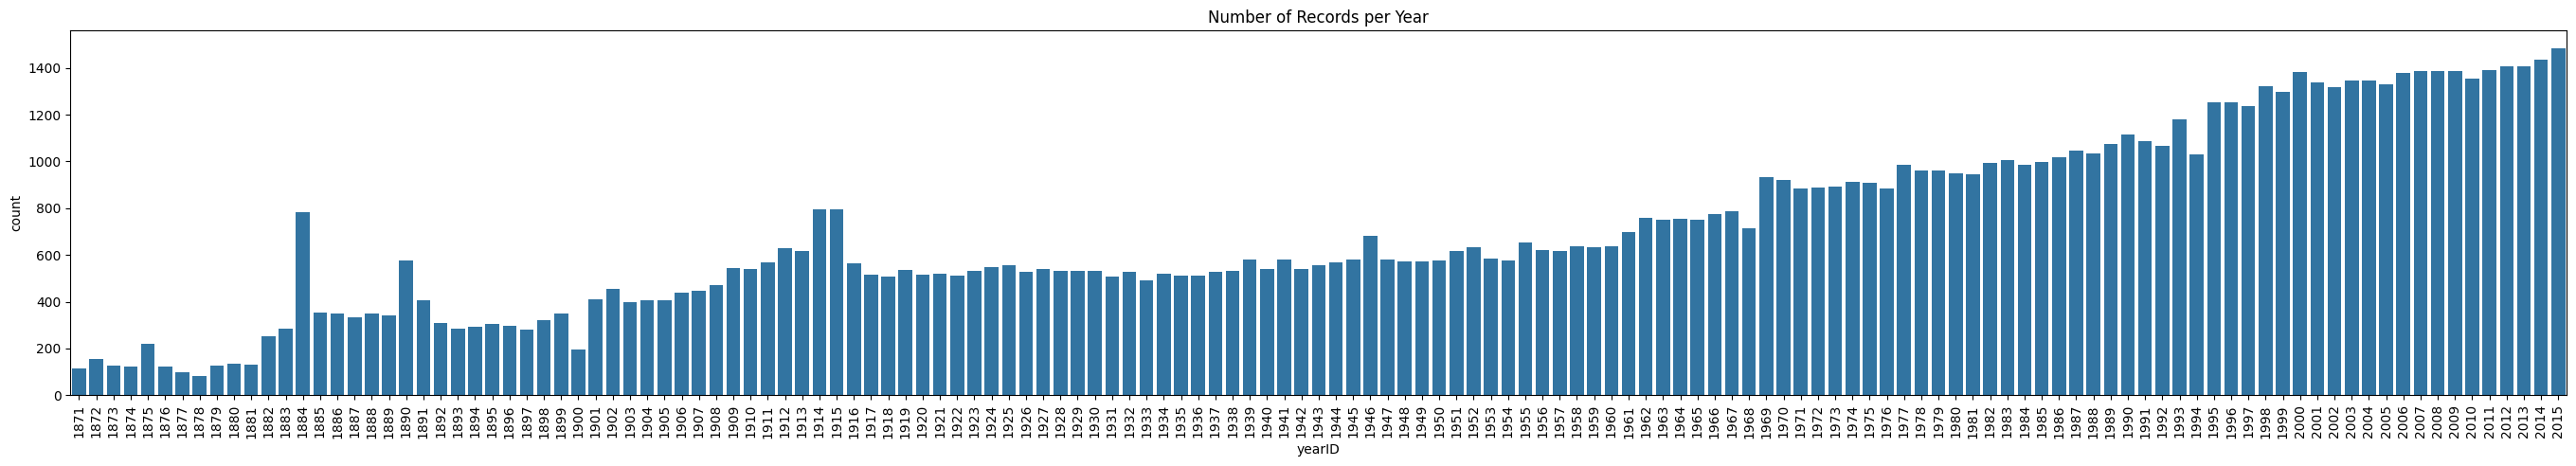

In [17]:
plt.figure(figsize=(34, 5))
sns.countplot(data=df, x='yearID')
plt.xticks(rotation=90)
plt.title('Number of Records per Year')
plt.show()

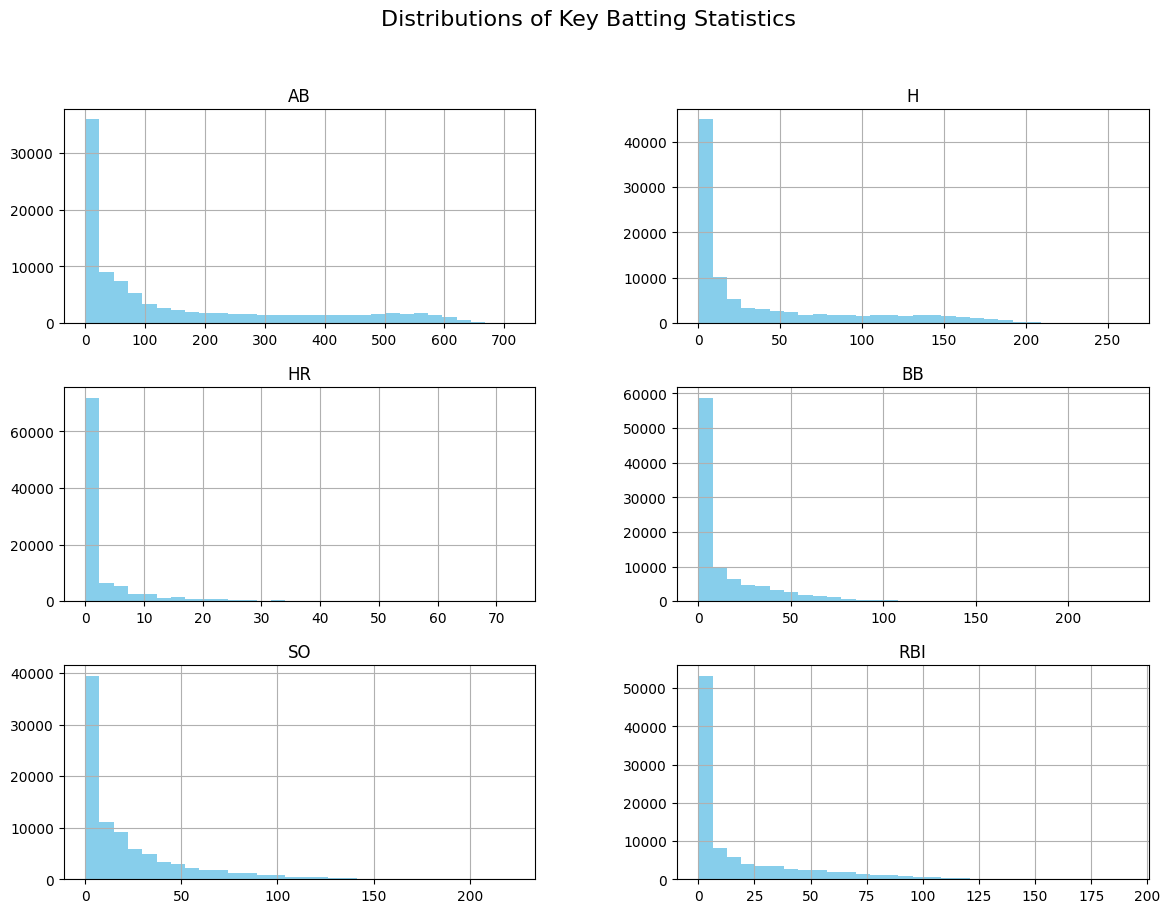

In [18]:
key_stats = ['AB', 'H', 'HR', 'BB', 'SO', 'RBI']
df[key_stats].hist(bins=30, figsize=(14, 10), color='skyblue')
plt.suptitle("Distributions of Key Batting Statistics", fontsize=16)
plt.show()

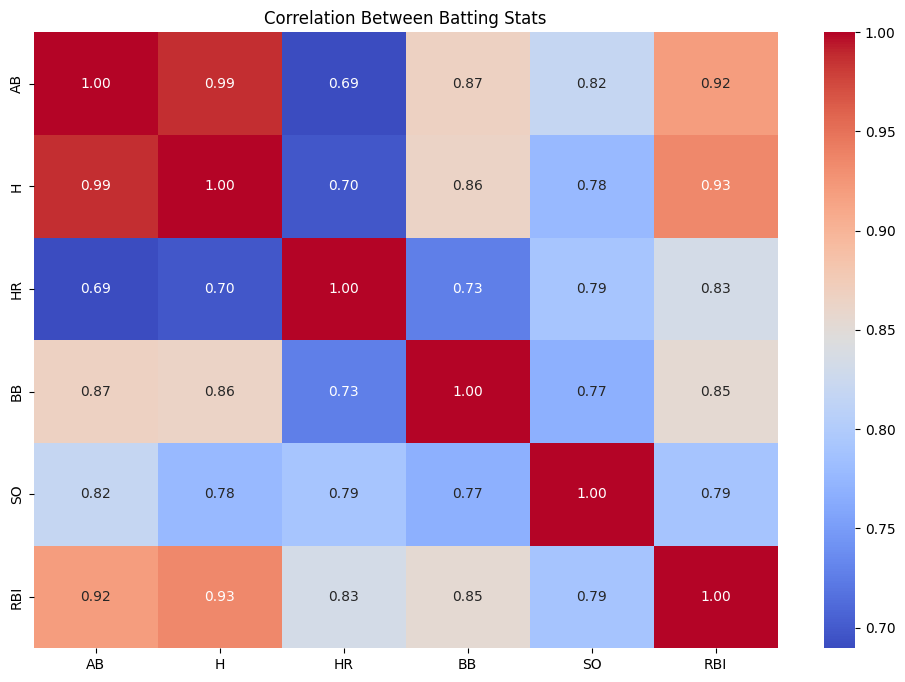

In [19]:
plt.figure(figsize=(12, 8))
corr = df[key_stats].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Between Batting Stats")
plt.show()

# Cleaning and Limiting

- Dropped empty records.
- Remove records with less than 400 AB

In [20]:
required_columns = ['HR', 'AB']
df = df.dropna(subset=required_columns)
df = df[df['AB'] >= 400]

# Lag Features

Create 3 lag features for `'AB'` and `'HR'` 

In [21]:
df = df.sort_values(by=['playerID', 'yearID'])
for col in required_columns:
    df[f'{col}_lag1'] = df.groupby('playerID')[col].shift(1)
    df[f'{col}_lag2'] = df.groupby('playerID')[col].shift(2)
    df[f'{col}_lag3'] = df.groupby('playerID')[col].shift(3)

lag_features = [f'{col}_lag1' for col in required_columns] + [f'{col}_lag2' for col in required_columns] + [f'{col}_lag3' for col in required_columns]
df = df.dropna(subset=lag_features)

# Normalize HR per AB

In [22]:
df['HR_per_AB'] = df['HR'] / df['AB']
df['HR_per_AB_lag1'] = df['HR_lag1'] / df['AB_lag1']
df['HR_per_AB_lag2'] = df['HR_lag2'] / df['AB_lag2']
df['HR_per_AB_lag3'] = df['HR_lag3'] / df['AB_lag3']

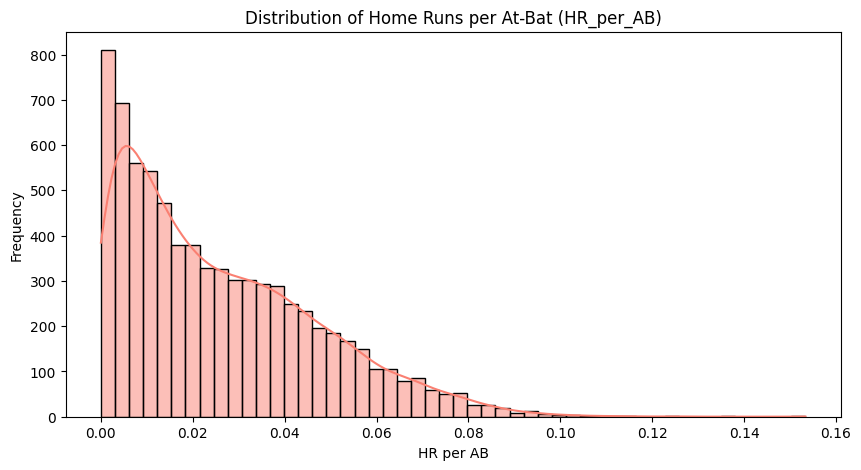

In [23]:
plt.figure(figsize=(10, 5))
sns.histplot(df['HR_per_AB'], bins=50, kde=True, color='salmon')
plt.title("Distribution of Home Runs per At-Bat (HR_per_AB)")
plt.xlabel("HR per AB")
plt.ylabel("Frequency")
plt.show()

# Data Split

Split into training and validation dataset according to 8/2 ratio

In [24]:
unique_years = sorted(df['yearID'].unique())
split_idx = int(len(unique_years) * 0.8)
split_year = unique_years[split_idx]

train_df = df[df['yearID'] < split_year]
val_df = df[df['yearID'] >= split_year]

# Axis

In [25]:
feature_cols = ['HR_per_AB_lag1', 'HR_per_AB_lag2', 'HR_per_AB_lag3']
target_col = 'HR_per_AB'

X_train = train_df[feature_cols]
y_train = train_df[target_col]
X_val = val_df[feature_cols]
y_val = val_df[target_col]

# RandomForestRegressor

In [26]:
# RandomForestRegressor comparison
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_val)
rf_mse = mean_squared_error(y_val, rf_pred)
rf_r2 = r2_score(y_val, rf_pred)

print("Random Forest Model Results:")
print(f"Mean Squared Error: {rf_mse:.6f}")
print(f"R² Score: {rf_r2:.3f}")

Random Forest Model Results:
Mean Squared Error: 0.000172
R² Score: 0.607


# Scatter plot: Random Forest predictions vs actual

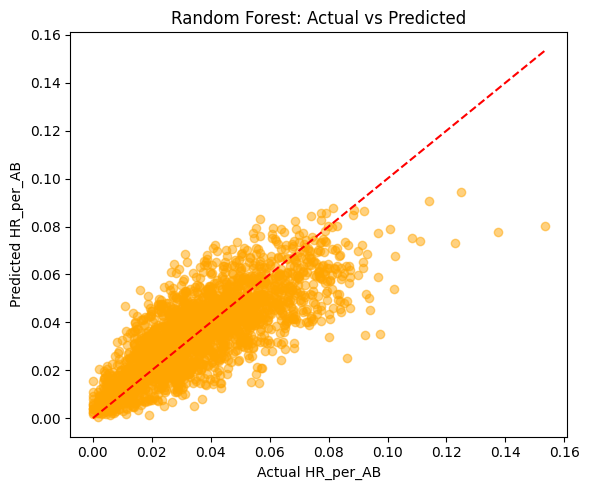

In [27]:
# Scatter plot: Random Forest predictions vs actual
plt.figure(figsize=(6, 5))
plt.scatter(y_val, rf_pred, alpha=0.5, color='orange')
plt.xlabel('Actual HR_per_AB')
plt.ylabel('Predicted HR_per_AB')
plt.title('Random Forest: Actual vs Predicted')
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
plt.tight_layout()
plt.show()

# Distribution comparison: training vs validation for each feature

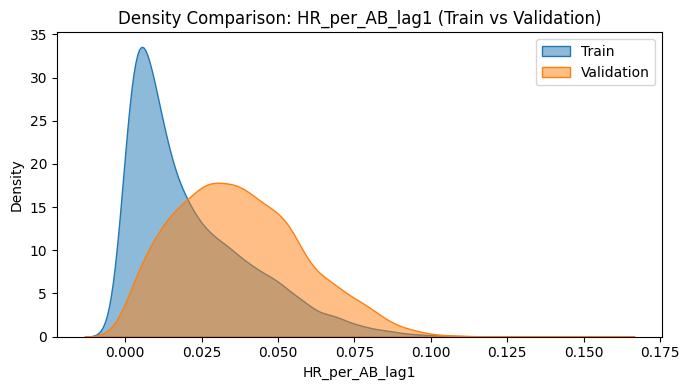

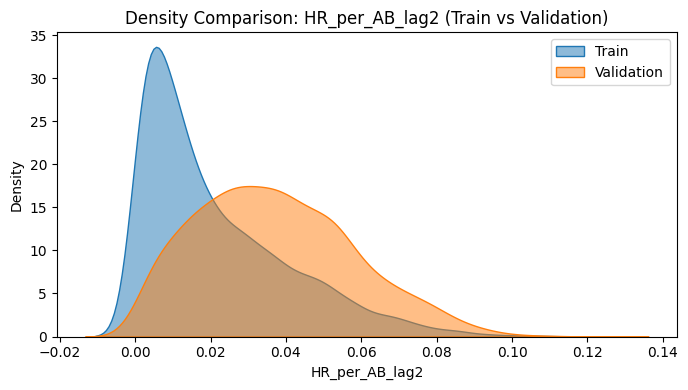

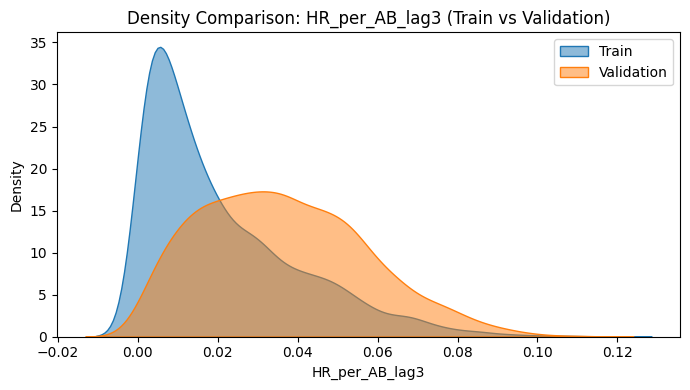

In [28]:
for col in feature_cols:
    plt.figure(figsize=(7, 4))
    sns.kdeplot(train_df[col], label='Train', fill=True, alpha=0.5)
    sns.kdeplot(val_df[col], label='Validation', fill=True, alpha=0.5)
    plt.title(f'Density Comparison: {col} (Train vs Validation)')
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.legend()
    plt.tight_layout()
    plt.show()

# Extract model

In [29]:
import joblib

joblib.dump(rf_model, "random_forest.pkl")

['random_forest.pkl']